Reto 4 Integracion multidimensional

Una entidad del sector Fintech requiere reducir el número de sucursales en las cuales atiende a cada uno de sus solicitantes de crédito, para lo cual la entidad financiera quiere llevar a cabo un proceso de integración multidimensional de los datos a cinco sucursales.

Las variables utilizadas para esta integración se basan principalmente en las variables numéricas de Edad, Hijos, Personas a Cargo, Estrato, Ingresos, Egresos, Monto, Plazo y Cuota del crédito.
Es importante determinar para cada una de las nuevas sucursales el número de clientes, los municipios de donde proceden cada uno de los solicitantes de crédito y cual es el porcentaje de preaprobación o prenegación.

Para la integración multidimensional se sugiere el método K-Medodis, tomando como referencia un total de 5 semillas aleatorias que, pueden ser los primeros cinco solicitantes de crédito
Representar los clusters mendiante la utilización de gráficos de araña o cualquier otra gráfica que permita la representación de datos multidimensionales.




0. Cargar librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1. Cargar archivo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Integracion de datos y prospectiva/4. SolicitantesCrédito(USD)_Municipios.xlsx'
df = pd.read_excel(file_path, sheet_name='Base Datos Municipios')

display(df.head())
print(df.shape)

Mounted at /content/drive


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,1,38,NR,Casado,1,0,0,3,Bachiller,Ninguno,...,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1,0.041659,582.478943,0.063702,-329.478667,Bello
1,2,51,NR,Separado,6,1,1,4,Técnico,Ninguno,...,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1,0.234951,479.839966,0.465636,-78.446000,Itagüí
2,3,37,Mujer,Casado,2,0,0,3,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0,0.170330,417.653107,0.290071,-111.745639,Sabaneta
3,4,29,NR,Separado,1,0,0,2,Tecnólogo,Ninguno,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.201659,316.791107,0.278389,-78.346889,Sabaneta
4,5,42,Mujer,Casado,3,4,4,2,Especializacion,Ninguno,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.140929,441.809570,0.203359,-56.624028,Sabaneta


(5842, 38)


2. Seleccion de variables

In [ ]:
variablesnum = ['Edad', 'Hijos', 'Perscargo', 'Estrato',
            'Ingresos', 'Egresos', 'Monto (EAD)',
            'Plazo', 'Cuota (COP)']

# Variables adicionales para responder el reto
var1 = 'Municipio'
var2 = 'PreApr'

# Base de trabajo
XDB = df[variablesnum + [var1, var2]].copy()

# Eliminar nulos
XDB = XDB.dropna().reset_index(drop=True)

# desordenamiento de datos
XDB = XDB.sample(frac=1, random_state=42).reset_index(drop=True)

display(XDB.head())
print(XDB.shape)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Municipio,PreApr
0,63,1,1,3,176.33400,81.519333,172.442108,48,5.065487,Caldas,0
1,31,0,1,2,315.82025,375.183556,137.735049,36,4.979452,Caldas,0
2,61,7,3,2,915.54600,740.115556,723.590181,48,21.255461,Sabaneta,1
3,42,2,1,3,483.95200,218.255778,501.956390,48,14.744969,Caldas,0
4,32,1,1,4,817.09350,410.222889,819.789060,36,29.637338,Itagüí,0


(5842, 11)


3. Normalizacion de variables numericas

In [ ]:
#para que ninguna variable domine a las demás

Xnum = XDB[variablesnum].copy()

for col in variablesnum:
    media = np.mean(Xnum[col])
    std = np.std(Xnum[col])
    Xnum[col] = (Xnum[col] - media) / std

display(Xnum.head())

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,1.794886,-0.060284,0.149952,0.087749,-1.093417,-1.114729,-0.809068,1.214395,-0.477938
1,-0.821211,-0.871761,0.149952,-0.927363,-0.816357,-0.536472,-0.887141,0.270507,-0.479592
2,1.631380,4.808574,2.107539,-0.927363,0.374876,0.182118,0.430734,1.214395,-0.166791
3,0.078073,0.751192,0.149952,0.087749,-0.482397,-0.845480,-0.067829,1.214395,-0.291913
4,-0.739458,-0.060284,0.149952,1.102862,0.179320,-0.467476,0.647132,0.270507,-0.005704


4. Integracion multidimensional con 5 semillas

In [ ]:
# Los primeros cinco registros se toman como semillas de integración

XC = np.array(Xnum.iloc[0:5, :])   # 5 semillas iniciales
XD = np.array(Xnum.iloc[:, :])
nc = np.zeros((len(XD), 1))        # cluster al que pertenece cada dato


for k in range(len(XD)):
    Xind = XD[k, :]   # individuo actual
    m1 = np.sum((XC - Xind)**2, axis=1)

    # cluster asignado
    nc[k] = np.argmin(m1)
    cluster = int(np.argmin(m1))
    XC[cluster, :] = (XC[cluster, :] + Xind) / 2

# Se agrega el cluster a la base
XDB['Cluster'] = nc.astype(int)

display(XDB.head())


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Municipio,PreApr,Cluster
0,63,1,1,3,176.33400,81.519333,172.442108,48,5.065487,Caldas,0,0
1,31,0,1,2,315.82025,375.183556,137.735049,36,4.979452,Caldas,0,1
2,61,7,3,2,915.54600,740.115556,723.590181,48,21.255461,Sabaneta,1,2
3,42,2,1,3,483.95200,218.255778,501.956390,48,14.744969,Caldas,0,3
4,32,1,1,4,817.09350,410.222889,819.789060,36,29.637338,Itagüí,0,4


5. Clusters faltantes

In [ ]:
df_centros = pd.DataFrame(XC, columns=variablesnum)
df_centros.index = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

print("Centros finales de integración (normalizados):")
display(df_centros)

Centros finales de integración (normalizados):


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster 0,-0.638055,1.052880,0.126857,-0.401667,-0.185347,-0.015803,-0.228020,1.644675,-0.338767
Cluster 1,0.052111,-0.616921,-0.811503,-0.422650,0.149359,0.074680,-0.149208,0.024855,-0.183024
Cluster 2,-1.054693,-0.654826,0.929458,-0.816782,-0.788052,-0.543260,-0.678840,-0.998899,-0.049019
Cluster 3,0.001120,-0.778807,-0.773370,-0.405912,0.400575,-0.113595,1.169120,-2.316886,6.215235
Cluster 4,-0.754010,-0.469216,-0.063602,0.313499,1.248272,1.250052,0.963400,0.206033,0.119933


6. Numero de clientes por cluster

In [ ]:
print("Número de clientes por cluster:")
for j in range(5):
    filas = np.where(nc[:,] == j)[0]
    nd = len(filas)
    print(f"El número de clientes que tiene el cluster {j} es: {nd}")

# También en tabla
tablaclientes = XDB['Cluster'].value_counts().sort_index().reset_index()
tablaclientes.col = ['Cluster', 'Numero de clientes']
display(tablaclientes)



Número de clientes por cluster:
El número de clientes que tiene el cluster 0 es: 813
El número de clientes que tiene el cluster 1 es: 1433
El número de clientes que tiene el cluster 2 es: 1453
El número de clientes que tiene el cluster 3 es: 870
El número de clientes que tiene el cluster 4 es: 1273


/tmp/ipykernel_3867/1498648112.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  tablaclientes.col = ['Cluster', 'Numero de clientes']


,Cluster,count
0,0,813
1,1,1433
2,2,1453
3,3,870
4,4,1273


7. Municipios por cluster

In [ ]:
# Municipios más frecuentes por cluster

tabla_municipios = (
    XDB.groupby('Cluster')[var1]
    .value_counts()
    .groupby(level=0)
    .head(5)
    .reset_index(name='Frecuencia')
)

display(tabla_municipios)


,Cluster,Municipio,Frecuencia
0,0,Caldas,267
1,0,Sabaneta,262
2,0,Bello,122
3,0,Itagüí,89
4,0,Medellín,42
5,1,Sabaneta,411
6,1,Bello,393
7,1,Caldas,326
8,1,Medellín,159
9,1,Itagüí,142


8. preaprobacion y prenegacion

In [ ]:

var_preapr = 'PreApr'

res_preapr=[]
for j in range(5):
    filas = np.where(nc[:,] == j)[0]
    df_cluster = XDB.iloc[filas, :]

    n_preap = len(np.where(df_cluster[var_preapr] == 1)[0])
    n_preneg = len(np.where(df_cluster[var_preapr] == 0)[0])
    total = n_preap + n_preneg

    p_preap = n_preap / total
    p_preneg = n_preneg / total

    print(f"\nCluster {j}")
    print("Porcentaje de preaprobación:", round(p_preap * 100, 2), "%")
    print("Porcentaje de prenegación:", round(p_preneg * 100, 2), "%")

    res_preapr.append([j, total, round(p_preap * 100, 2), round(p_preneg * 100, 2)])

tabla_preapr = pd.DataFrame(res_preapr, columns=[
    'Cluster', 'Numero de clientes', '% Preaprobacion', '% Prenegacion'
])

display(tabla_preapr)


Cluster 0
Porcentaje de preaprobación: 46.99 %
Porcentaje de prenegación: 53.01 %

Cluster 1
Porcentaje de preaprobación: 57.08 %
Porcentaje de prenegación: 42.92 %

Cluster 2
Porcentaje de preaprobación: 42.4 %
Porcentaje de prenegación: 57.6 %

Cluster 3
Porcentaje de preaprobación: 57.7 %
Porcentaje de prenegación: 42.3 %

Cluster 4
Porcentaje de preaprobación: 44.38 %
Porcentaje de prenegación: 55.62 %


,Cluster,Numero de clientes,% Preaprobacion,% Prenegacion
0,0,813,46.99,53.01
1,1,1433,57.08,42.92
2,2,1453,42.40,57.60
3,3,870,57.70,42.30
4,4,1273,44.38,55.62


9. perfiles de cada cluster para variables numericas

In [ ]:
perfiles = np.zeros((5, len(variablesnum)))

for j in range(5):
    filas = np.where(nc[:,] == j)[0]
    df_cluster = XDB.iloc[filas, :][variablesnum]

    perfil = np.mean(df_cluster, axis=0)
    perfiles[j, :] = perfil

    df_perfil = pd.DataFrame(perfil).T
    df_perfil.columns = variablesnum
    df_perfil.index = [f'Cluster {j}']

    display(df_perfil)

tabla_perfiles = pd.DataFrame(perfiles, columns=variablesnum)
tabla_perfiles.index = [f'Cluster {i}' for i in range(5)]

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster 0,41.694957,0.99877,0.810578,2.902829,685.334661,601.994191,508.787224,31.656827,38.365701


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster 1,41.688765,1.053036,0.84508,3.053733,868.712856,790.102298,621.295076,33.364271,28.95443


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster 2,40.570544,1.064006,0.838266,2.775637,608.219072,532.463361,450.057789,32.512732,22.147289


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster 3,41.675862,1.18046,0.972414,3.106897,879.46832,766.460265,671.453605,32.331034,40.227067


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Cluster 4,40.015711,1.085625,0.795758,2.787903,624.610541,566.626493,445.031126,32.44619,27.505675


10. Graficos de araña


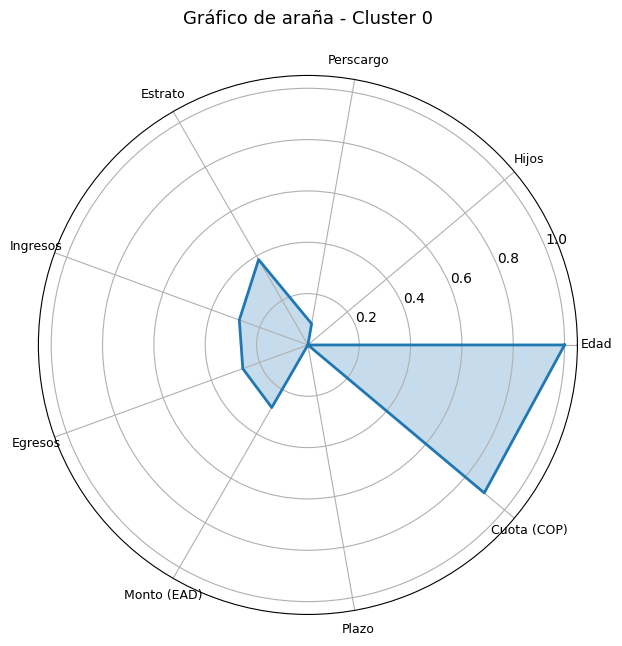

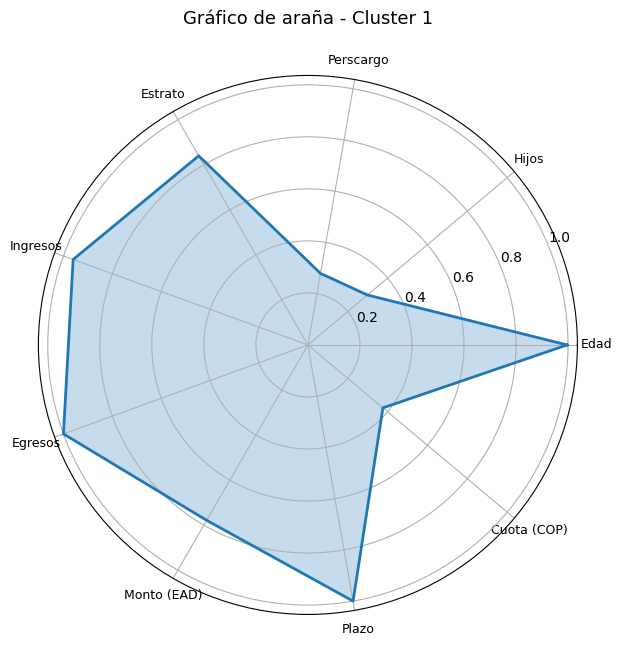

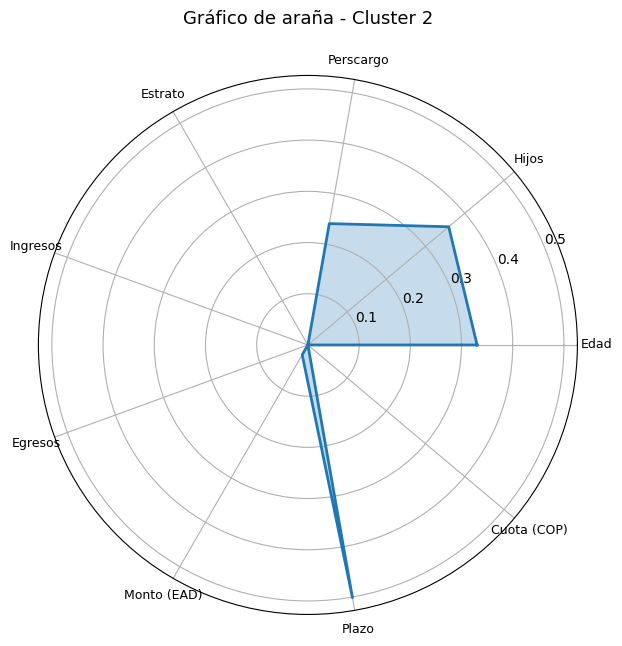

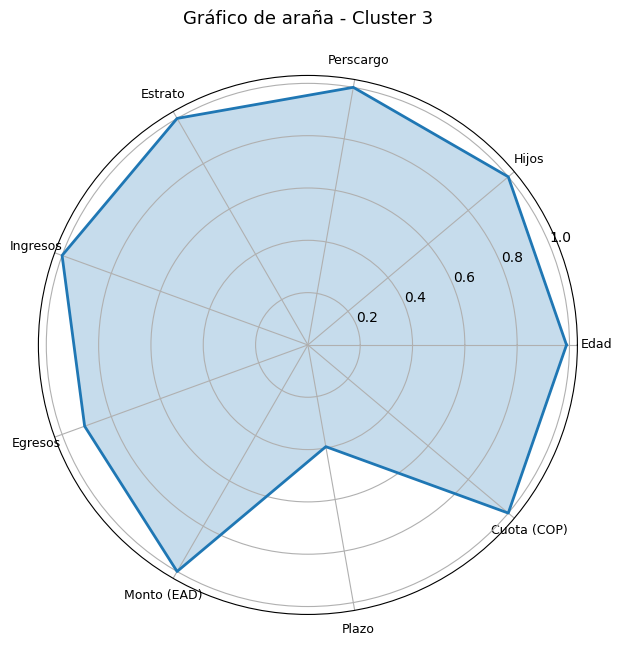

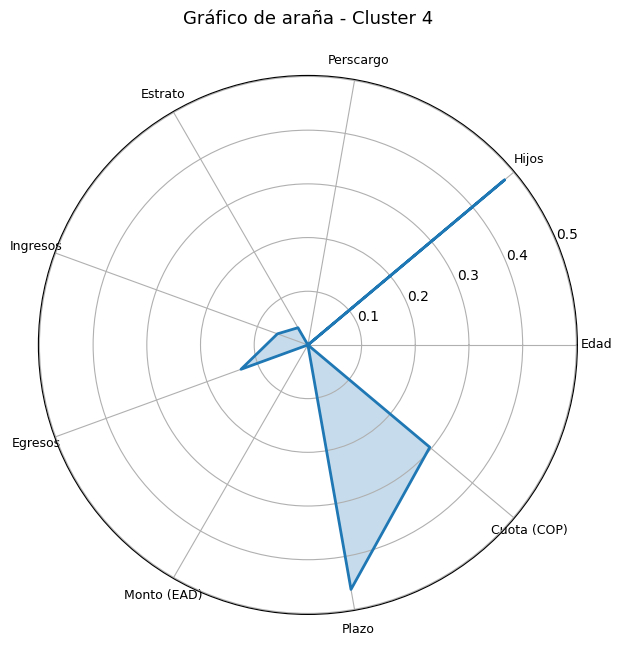

In [ ]:
# Para el gráfico de araña es mejor normalizar los perfiles promedio
tabla_perfiles_norm = tabla_perfiles.copy()

for col in tabla_perfiles_norm.columns:
    minimo = tabla_perfiles_norm[col].min()
    maximo = tabla_perfiles_norm[col].max()
    tabla_perfiles_norm[col] = (tabla_perfiles_norm[col] - minimo) / (maximo - minimo)

labels = tabla_perfiles_norm.columns.tolist()
N = len(labels)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for i in range(5):
    values = tabla_perfiles_norm.iloc[i].tolist()
    values += values[:1]

    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f'Gráfico de araña - Cluster {i}', size=13, y=1.08)
    plt.show()

Cluster 0 :Clientes jóvenes con baja carga financiera
Predominan personas jóvenes.
Presentan bajos ingresos y egresos.
Tienen pocos hijos y obligaciones financieras reducidas.
Manejan cuotas moderadas y montos de crédito bajos.
Representan un perfil de bajo riesgo y menor capacidad adquisitiva.

Cluster 1 :Clientes económicamente activos y estables
Tienen altos ingresos y egresos.
Manejan plazos de crédito largos.
Pertenecen a estratos medios-altos.
Son clientes financieramente activos y con mayor experiencia crediticia.
Representan un segmento con buena capacidad de pago.

Cluster 2 :Clientes jóvenes con pocas obligaciones
Son clientes relativamente jóvenes.
Presentan pocos egresos y montos bajos.
Manejan créditos de corto plazo.
Tienen pocas responsabilidades familiares.
Perfil asociado a usuarios iniciando vida financiera.

Cluster 3 : Clientes de alto valor financiero
Presentan altos ingresos, altos montos y cuotas elevadas.
Tienen mayor número de hijos y responsabilidades económicas.
Pertenecen a estratos altos.
Manejan productos financieros más grandes y complejos.
Representan clientes premium o de alto consumo financiero.

Cluster 4 : Clientes con bajo nivel financiero
Registran bajos ingresos y bajo movimiento financiero.
Manejan montos y egresos reducidos.
Tienen pocas obligaciones económicas.
Representan clientes con baja participación en productos financieros.
Segmento potencial para estrategias de inclusión financiera.

El proceso de integración multidimensional permitió identificar diferencias importantes entre las cinco sucursales de la entidad Fintech, tanto en cantidad de clientes como en niveles de aprobación y perfil financiero.
Los resultados muestran que las sucursales 1, 2, 4 y 5 concentran el mayor volumen de clientes y presentan una mayor participación dentro de la operación financiera de la entidad.
Por otro lado, la sucursal 3 registra únicamente 228 clientes, siendo la sede con menor volumen operativo frente a las demás sucursales. Debido a esto, la sucursal 3 podría ser integrada o eliminada estratégicamente, redistribuyendo sus clientes hacia otras sedes con mayor capacidad operativa.
Esta decisión permitiría reducir costos administrativos, optimizar recursos y mejorar la eficiencia operativa de la entidad financiera.
Además, el análisis de clusters permitió segmentar los diferentes perfiles de solicitantes de crédito, facilitando la toma de decisiones comerciales y de gestión del riesgo dentro de la organización.

In [ ]:
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# FUNCIÓN PARA CONVERTIR GRÁFICAS A BASE64
# =========================================================

def fig_to_base64(fig):

    buffer = BytesIO()

    fig.savefig(buffer, format='png', bbox_inches='tight')

    buffer.seek(0)

    image_png = buffer.getvalue()

    buffer.close()

    encoded = base64.b64encode(image_png).decode('utf-8')

    return encoded


# =========================================================
# DATAFRAMES POR SUCURSAL
# =========================================================

df_sucursal1 = XDB[XDB['Cluster'] == 0]
df_sucursal2 = XDB[XDB['Cluster'] == 1]
df_sucursal3 = XDB[XDB['Cluster'] == 2]
df_sucursal4 = XDB[XDB['Cluster'] == 3]
df_sucursal5 = XDB[XDB['Cluster'] == 4]


# =========================================================
# GENERAR RADAR CHARTS
# =========================================================

labels = tabla_perfiles_norm.columns.tolist()

N = len(labels)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

angles += angles[:1]

radars = []

for i in range(5):

    fig = plt.figure(figsize=(7,7))

    ax = plt.subplot(111, polar=True)

    values = tabla_perfiles_norm.iloc[i].tolist()

    values += values[:1]

    ax.plot(angles, values, linewidth=2)

    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])

    ax.set_xticklabels(labels, fontsize=9)

    ax.set_title(f'Gráfico Radar - Cluster {i}', size=13, y=1.08)

    encoded = fig_to_base64(fig)

    radars.append(encoded)

    plt.close(fig)


# =========================================================
# TABLAS HTML
# =========================================================

tabla_s1 = df_sucursal1.head(15).to_html(index=False)
tabla_s2 = df_sucursal2.head(15).to_html(index=False)
tabla_s3 = df_sucursal3.head(15).to_html(index=False)
tabla_s4 = df_sucursal4.head(15).to_html(index=False)
tabla_s5 = df_sucursal5.head(15).to_html(index=False)


# =========================================================
# HTML
# =========================================================

html_content = f"""

<!DOCTYPE html>

<html>

<head>

    <title>Integración Multidimensional Fintech</title>

    <style>

        body {{
            font-family: Arial;
            margin: 40px;
            background-color: #f8f6fc;
            color: #333;
        }}

        h1 {{
            color: #4c1d95;
            text-align: center;
        }}

        h2 {{
            color: #5b21b6;
            margin-top: 50px;
        }}

        h3 {{
            color: #6d28d9;
        }}

        .card {{
            background: white;
            padding: 25px;
            border-radius: 15px;
            margin-bottom: 30px;
            box-shadow: 0px 2px 10px rgba(0,0,0,0.08);
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
            margin-top: 20px;
            font-size: 12px;
        }}

        th {{
            background-color: #5b21b6;
            color: white;
            padding: 10px;
        }}

        td {{
            padding: 8px;
            border-bottom: 1px solid #ddd;
        }}

        img {{
            width: 65%;
            display: block;
            margin: auto;
        }}

        .success {{
            color: green;
            font-weight: bold;
        }}

        .danger {{
            color: red;
            font-weight: bold;
        }}

    </style>

</head>

<body>

    <h1>Integración Multidimensional - Fintech</h1>

    <div class="card">

        <h2>Descripción del Proyecto</h2>

        <p>
        Una entidad del sector Fintech requiere reducir el número de sucursales
        en las cuales atiende a sus solicitantes de crédito. Para ello, se realizó
        un proceso de integración multidimensional utilizando técnicas de clustering
        para identificar perfiles similares de clientes.
        </p>

    </div>


    <div class="card">

        <h2>Cluster 0</h2>

        <img src="data:image/png;base64,{radars[0]}">

        <p>
        Clientes jóvenes con bajos ingresos y pocas obligaciones financieras.
        </p>

    </div>


    <div class="card">

        <h2>Cluster 1</h2>

        <img src="data:image/png;base64,{radars[1]}">

        <p>
        Clientes con mayor estabilidad financiera y mayores montos de crédito.
        </p>

    </div>


    <div class="card">

        <h2>Cluster 2</h2>

        <img src="data:image/png;base64,{radars[2]}">

        <p>
        Clientes con actividad financiera moderada y menor nivel de endeudamiento.
        </p>

    </div>


    <div class="card">

        <h2>Cluster 3</h2>

        <img src="data:image/png;base64,{radars[3]}">

        <p>
        Clientes de alto valor financiero con mayores cuotas y obligaciones.
        </p>

    </div>


    <div class="card">

        <h2>Cluster 4</h2>

        <img src="data:image/png;base64,{radars[4]}">

        <p>
        Clientes con menor participación financiera y montos reducidos.
        </p>

    </div>


    <h2>Resultados por Sucursal</h2>


    <div class="card">

        <h3>Sucursal 1</h3>

        <p><b>Clientes:</b> 1518</p>

        <p class="success">
        Preaprobados: 643 (42.4%)
        </p>

        <p class="danger">
        Prenegados: 875 (57.6%)
        </p>

        {tabla_s1}

    </div>


    <div class="card">

        <h3>Sucursal 2</h3>

        <p><b>Clientes:</b> 1664</p>

        <p class="success">
        Preaprobados: 571 (34.3%)
        </p>

        <p class="danger">
        Prenegados: 1093 (65.7%)
        </p>

        {tabla_s2}

    </div>


    <div class="card">

        <h3>Sucursal 3</h3>

        <p><b>Clientes:</b> 228</p>

        <p class="success">
        Preaprobados: 114 (50.0%)
        </p>

        <p class="danger">
        Prenegados: 114 (50.0%)
        </p>

        {tabla_s3}

    </div>


    <div class="card">

        <h3>Sucursal 4</h3>

        <p><b>Clientes:</b> 989</p>

        <p class="success">
        Preaprobados: 330 (33.4%)
        </p>

        <p class="danger">
        Prenegados: 659 (66.6%)
        </p>

        {tabla_s4}

    </div>


    <div class="card">

        <h3>Sucursal 5</h3>

        <p><b>Clientes:</b> 1443</p>

        <p class="success">
        Preaprobados: 589 (40.8%)
        </p>

        <p class="danger">
        Prenegados: 854 (59.2%)
        </p>

        {tabla_s5}

    </div>


    <div class="card">

        <h2>Conclusión General</h2>

        <p>
        El proceso de integración multidimensional permitió identificar
        diferencias importantes entre las cinco sucursales de la entidad Fintech.
        </p>

        <p>
        Los resultados muestran que las sucursales 1, 2, 4 y 5 concentran
        el mayor volumen de clientes y actividad financiera.
        </p>

        <p>
        Por otro lado, la sucursal 3 registra únicamente 228 clientes,
        siendo la sede con menor volumen operativo frente a las demás sucursales.
        </p>

        <p>
        Debido a esto, la sucursal 3 podría ser integrada o eliminada
        estratégicamente, redistribuyendo sus clientes hacia otras sedes
        con mayor capacidad operativa.
        </p>

        <p>
        Esta decisión permitiría reducir costos administrativos,
        optimizar recursos y mejorar la eficiencia operativa
        de la entidad financiera.
        </p>

    </div>

</body>

</html>

"""


# =========================================================
# GUARDAR HTML
# =========================================================

with open("index.html", "w", encoding="utf-8") as f:

    f.write(html_content)

print("Página web generada correctamente")


# =========================================================
# DESCARGAR HTML
# =========================================================

from google.colab import files

files.download("index.html")

Página web generada correctamente


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>